FIAP

# TIAO - Machine Learning - Aula 03

## Algoritmos supervisionados - Regressão

Estudo de caso do dataset **Galton**, disponível no [Kaggle](https://www.kaggle.com/datasets/jaorcovre/galton-height-data).

Este dataset contém informações sobre altura dos pais, com o objetivo de _prever a altura dos filhos na idade adulta_.



In [ ]:
# Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# Ler o dataset
df = pd.read_csv("galton.csv")
df.head(5)

,family,father,mother,midparentHeight,children,childNum,gender,childHeight
0,1,78.5,67.0,75.43,4,1,male,73.2
1,1,78.5,67.0,75.43,4,2,female,69.2
2,1,78.5,67.0,75.43,4,3,female,69.0
3,1,78.5,67.0,75.43,4,4,female,69.0
4,2,75.5,66.5,73.66,4,1,male,73.5


In [ ]:
# Infos do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   family           934 non-null    object 
 1   father           934 non-null    float64
 2   mother           934 non-null    float64
 3   midparentHeight  934 non-null    float64
 4   children         934 non-null    int64  
 5   childNum         934 non-null    int64  
 6   gender           934 non-null    object 
 7   childHeight      934 non-null    float64
dtypes: float64(4), int64(2), object(2)
memory usage: 58.5+ KB


In [ ]:
# Removendo linhas duplicadas
df.drop_duplicates(inplace=True)

# Tratamento de dados - REMOVENDO COLUNAS INÚTEIS PARA O PROBLEMA
df.drop(columns=["family", "children", "childNum"], inplace=True)

# Tratamento de dados - PASSANDO DE INCHES PARA METROS
def inch2m(inch):
  return inch*2.54/100

for coluna in ["father", "mother", "midparentHeight", "childHeight"]:
  df[coluna] = df[coluna].apply( inch2m )

# Tratamento de dados - PASSANDO "GENDER" DE STRING PARA NÚMERO
df["gender"] = df["gender"].apply( lambda x: 0 if x=="male" else 1 )

# Tratamento de dados - CRIAR UMA COLUNA COM A MÉDIA DA ALTURA DOS PAIS
df["media"] = (df["father"] + df["mother"]) / 2

# Exibe o resultado
df.sample(5)

,father,mother,midparentHeight,gender,childHeight,media
353,1.7780,1.61798,1.762709,1,1.60528,1.69799
530,1.7653,1.57480,1.733042,1,1.63830,1.67005
659,1.7272,1.60020,1.727708,0,1.70180,1.66370
372,1.7780,1.60020,1.753108,1,1.61798,1.68910
449,1.7526,1.68910,1.788414,0,1.67640,1.72085


## Modelagem das regressões

### Regressão simples

OBS: como o X e o Y estão na mesma escala, não preciso padronizar as variáveis!

In [ ]:
# Dados e labels
X = np.array( df["media"] ).reshape(-1, 1) # Só fiz o reshape pq estou usando apenas 1 coluna do df
y = df["childHeight"]

# Treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Treinar o modelo
reta = LinearRegression()
reta.fit(X_train, y_train)

y_pred = reta.predict(X_test)

# Avaliar o modelo
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE = {mse}")
print(f"MAE = {mae}")
print(f"R² = {r2}")

MSE = 0.0076515087487540635
MAE = 0.07409180708927149
R² = 0.1283802341245447


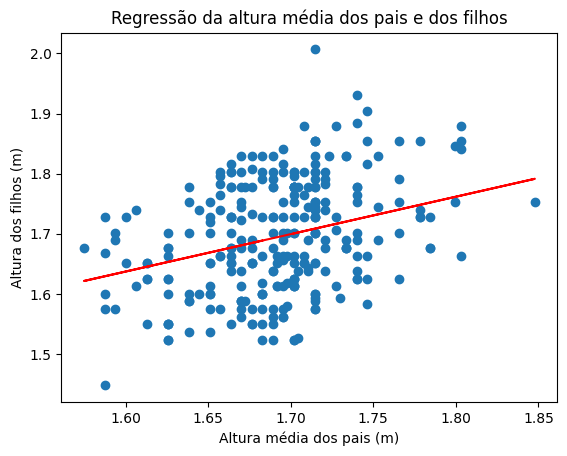

In [ ]:
# Gráfico da regressão simples
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color="red")
plt.title("Regressão da altura média dos pais e dos filhos")
plt.xlabel("Altura média dos pais (m)")
plt.ylabel("Altura dos filhos (m)")
plt.show()

### Regressão múltipla

In [ ]:
# Dados e labels
X = df.drop(columns=["childHeight", "midparentHeight"])
y = df["childHeight"]

# Treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Padronização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinar o modelo
reta2 = LinearRegression()
reta2.fit(X_train_scaled, y_train)
y_pred = reta2.predict(X_test_scaled)

# Avaliar o modelo (só copiei da célula da regressão simples)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE = {mse}")
print(f"MAE = {mae}")
print(f"R² = {r2}")

MSE = 0.003050348288408433
MAE = 0.043282428624405976
R² = 0.6525203135376285


In [ ]:
X_train

In [ ]:
# Outros modelos!
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# Dados e labels (usando os mesmos que a regressão múltipla)
X = df.drop(columns=["childHeight", "midparentHeight"])
y = df["childHeight"]

# Treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Padronização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dicionário para armazenar os resultados de cada modelo
results = {}

# Função para treinar e avaliar o modelo
def evaluate_model(model, model_name):
  model.fit(X_train_scaled, y_train)
  y_pred = model.predict(X_test_scaled)
  mse = mean_squared_error(y_test, y_pred)
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  results[model_name] = {'mse': mse, 'mae': mae, 'r2': r2}
  print(f"{model_name}:")
  print(f"  MSE = {mse}")
  print(f"  MAE = {mae}")
  print(f"  R² = {r2}")


# XGBoost
xgb_model = xgb.XGBRegressor()
evaluate_model(xgb_model, 'XGBoost')

# SVM
svm_model = SVR()
evaluate_model(svm_model, 'SVM')

# KNN
knn_model = KNeighborsRegressor()
evaluate_model(knn_model, 'KNN')

# Árvore de Decisão
tree_model = DecisionTreeRegressor()
evaluate_model(tree_model, 'Decision Tree')

# Random Forest
rf_model = RandomForestRegressor()
evaluate_model(rf_model, 'Random Forest')

# Comparação dos modelos
print("\nComparação dos modelos:")
results_df = pd.DataFrame(results).transpose()
print(results_df)


XGBoost:
  MSE = 0.0035442079757330275
  MAE = 0.04574885187481647
  R² = 0.5962624068716678
SVM:
  MSE = 0.0034272786986579294
  MAE = 0.04595990378168548
  R² = 0.6095823771487426
KNN:
  MSE = 0.0032045625266903933
  MAE = 0.04394651957295374
  R² = 0.6349530359353032
Decision Tree:
  MSE = 0.0034600188030727897
  MAE = 0.0454159006165839
  R² = 0.6058527960841631
Random Forest:
  MSE = 0.003381542372067695
  MAE = 0.04470130983015832
  R² = 0.6147924197146712

Comparação dos modelos:
                    mse       mae        r2
XGBoost        0.003544  0.045749  0.596262
SVM            0.003427  0.045960  0.609582
KNN            0.003205  0.043947  0.634953
Decision Tree  0.003460  0.045416  0.605853
Random Forest  0.003382  0.044701  0.614792


In [ ]:
# Intercept
display("Intercept: ", reta2.intercept_)

# Coeficientes
pd.DataFrame( {"features": X_train.columns,
               "coeficientes": reta2.coef_})